# Ejercicio 4 


In [50]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

Vamos a construir las matrices de datos W apartir de una matriz D. 
Los elementos de la matriz tienen media cero y desviasión estándar 1. Además de que en este mismo código calculamos los autovalores reales. El código lo reciclamos del ejercicio anterior.

In [61]:


def matriz_wishart(N, T):
    D = np.random.normal(0, 1, size=(N, T))
    W = (D @ D.T) / T
    return W 


autovalores_WOE = []


for i in range(miembros):
    W = matriz_wishart(N, T)
    autovalores = np.linalg.eigvalsh(W)
    autovalores_WOE.extend(autovalores)

Ahora vamos a construir la matriz X_n_n con valores en la diagonal c 
Los valores de c van a variar c = 0, 0.2, 0.5 y 0.9

In [51]:
def Xi(N, c):
    Xi = np.full((N,N),c, dtype= float)
    np.fill_diagonal(Xi, 1)
    return Xi


Vamos a construir los datos correlacionados $X = X_{n}^{1/2}* D$

In [74]:

def matriz_D(N, T):
    D = np.random.normal(0, 1, size=(N, T))
    return D
def X(N,T,c):
    D = matriz_D(N, T)
    Xi_mat = Xi(N, c)
    Xi_sqrt = sqrtm(Xi_mat)
    X = Xi_sqrt @ D
    return X

def C(N,T,c):
    X_math = X(N,T,c)
    C = (X_math @ X_math.T) / T
    return C


In [75]:
N = 200
T = 500
c = 0.1
C(N,T,c)

array([[0.93162902, 0.16531303, 0.06795812, ..., 0.15272357, 0.09946276,
        0.17515655],
       [0.16531303, 0.94831798, 0.14179226, ..., 0.08756191, 0.16794163,
        0.05438478],
       [0.06795812, 0.14179226, 1.02701608, ..., 0.13199965, 0.04946155,
        0.01915515],
       ...,
       [0.15272357, 0.08756191, 0.13199965, ..., 1.05083602, 0.01015011,
        0.1183631 ],
       [0.09946276, 0.16794163, 0.04946155, ..., 0.01015011, 1.04826028,
        0.10779153],
       [0.17515655, 0.05438478, 0.01915515, ..., 0.1183631 , 0.10779153,
        0.94446108]], shape=(200, 200))

In [87]:
autovalores_C = [[], [], [], []]
N = 200
T = 500
c = 0.1
miembros = 100
c =  [0, 0.2, 0.5,  0.9]
for j, valor in enumerate(c):
    for i in range(miembros):
        C_math = C(N,T,valor)
        autovalores = np.linalg.eigvalsh(C_math)
        autovalores_C[j].extend(autovalores)
    autovalores_C[j] = np.array(autovalores_C[j])


(array([1.99e+04, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 8.00e+00, 6.30e+01, 2.90e+01]),
 array([1.30073166e-02, 2.05999149e+01, 4.11868225e+01, 6.17737300e+01,
        8.23606376e+01, 1.02947545e+02, 1.23534453e+02, 1.44121360e+02,
        1.64708268e+02, 1.85295175e+02, 2.05882083e+02]),
 <BarContainer object of 10 artists>)

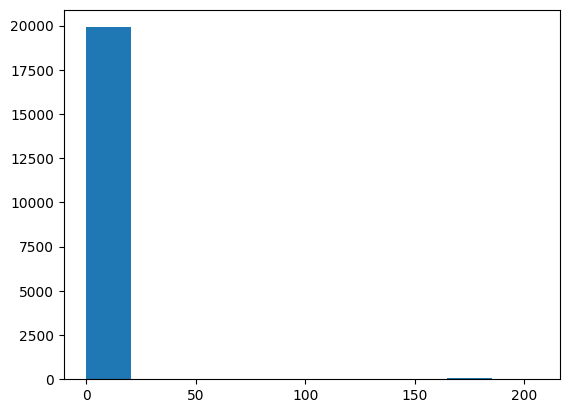

In [96]:
plt.hist(autovalores_C[3])
